In [3]:
!git clone https://github.com/venkatsaikondra/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification.git

Cloning into 'CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification'...
remote: Enumerating objects: 32713, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 32713 (delta 2), reused 14 (delta 2), pack-reused 32697 (from 1)
Receiving objects: 100% (32713/32713), 360.21 MiB | 38.57 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Updating files: 100% (75833/75833), done.


In [4]:
import os
os.chdir("CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification")

In [5]:
!ls

CNN		    Data_Augumentation	Equal_sample  Train_Test_Split_CNN_Data
CNN_Augmented_Data  Data_Collection	Raw	      Unique_Raw


In [6]:
from PIL import Image
import os

folder_path = "/content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/CNN_Augmented_Data/Covid-19"

for file in os.listdir(folder_path):
    if file.endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(folder_path, file)
        with Image.open(img_path) as img:
            print(f"{file} -> {img.size}")  # (width, height)

Streaming output truncated to the last 5000 lines.
aug_COVID-17.jpg -> (224, 224)
orig_COVID-19 (576).jpg -> (224, 224)
orig_COVID-3025.jpg -> (224, 224)
orig_COVID-2231.jpg -> (224, 224)
orig_COVID-1855.jpg -> (224, 224)
aug_COVID-2855.jpg -> (224, 224)
aug_COVID-19 (765).jpg -> (224, 224)
aug_COVID-19 (753).jpg -> (224, 224)
aug_COVID-20.jpg -> (224, 224)
orig_COVID-3123.jpg -> (224, 224)
orig_COVID-19 (412).jpg -> (224, 224)
aug_COVID-980.jpg -> (224, 224)
aug_COVID-19 (838).jpg -> (224, 224)
orig_COVID-3379.jpg -> (224, 224)
aug_COVID-3077.jpg -> (224, 224)
aug_COVID-653.jpg -> (224, 224)
aug_COVID-19 (1090).jpg -> (224, 224)
orig_COVID-3102.jpg -> (224, 224)
aug_COVID-1917.jpg -> (224, 224)
orig_COVID-679.jpg -> (224, 224)
orig_COVID-19 (81).jpg -> (224, 224)
aug_COVID-19 (801).jpg -> (224, 224)
aug_COVID-1411.jpg -> (224, 224)
orig_COVID-19 (230).jpg -> (224, 224)
orig_COVID-19 (618).jpg -> (224, 224)
orig_COVID-204.jpg -> (224, 224)
aug_COVID-2208.jpg -> (224, 224)
orig_COVID-19

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

def AlexNet(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([
        # 1st Convolutional Layer
        layers.Conv2D(filters=96, kernel_size=(11, 11), strides=(4, 4), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

        # 2nd Convolutional Layer
        layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

        # 3rd Convolutional Layer
        layers.Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding="same"),
        layers.BatchNormalization(),

        # 4th Convolutional Layer
        layers.Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding="same"),
        layers.BatchNormalization(),

        # 5th Convolutional Layer
        layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

        # Passing it to a dense layer
        layers.Flatten(),

        # 1st Dense Layer
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        # 2nd Dense Layer
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create the model
model = AlexNet(input_shape=(224, 224, 3), num_classes=4)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,768,900 (178.41 MB)

 Trainable params: 46,766,148 (178.40 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [8]:
import tensorflow as tf

# Standard Colab path if you uploaded the folder directly to the 'Files' tab
base_path = "/content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/Train_Test_Split_CNN_Data"

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/val",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

Found 17252 files belonging to 4 classes.
Found 2156 files belonging to 4 classes.


In [9]:

history = model.fit(train_ds, validation_data=val_ds, epochs=25)

Epoch 1/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - accuracy: 0.6373 - loss: 1.3133 - val_accuracy: 0.6294 - val_loss: 0.8096
Epoch 2/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.7296 - loss: 0.6606 - val_accuracy: 0.5037 - val_loss: 1.3725
Epoch 3/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.7617 - loss: 0.5531 - val_accuracy: 0.6146 - val_loss: 0.8647
Epoch 4/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.7807 - loss: 0.5065 - val_accuracy: 0.7263 - val_loss: 0.6234
Epoch 5/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.7990 - loss: 0.4699 - val_accuracy: 0.7157 - val_loss: 0.6137
Epoch 6/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.8126 - loss: 0.4398 - val_accuracy: 0.6350 - val_loss: 1.0244
Epoch 7/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.8181 - loss: 0.4241 - val_accuracy: 0.7913 - val_loss: 0.5026
Epoch 8/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.8323 - loss: 0.3928 - 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.utils import to_categorical

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/Train_Test_Split_CNN_Data/test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)

y_true = []
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']

Found 2160 files belonging to 4 classes.
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step


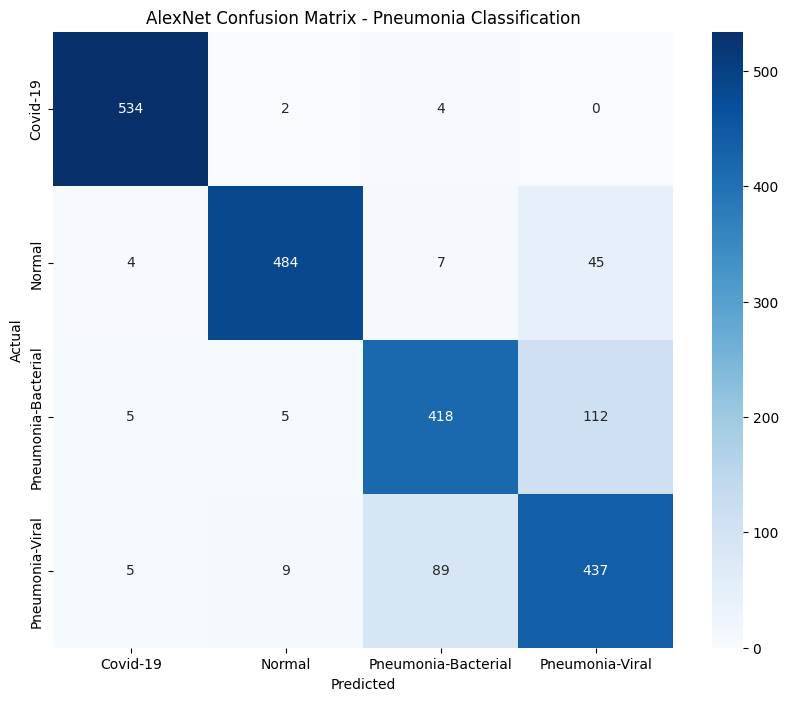

In [11]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('AlexNet Confusion Matrix - Pneumonia Classification')
plt.show()

In [12]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

                     precision    recall  f1-score   support

           Covid-19       0.97      0.99      0.98       540
             Normal       0.97      0.90      0.93       540
Pneumonia-Bacterial       0.81      0.77      0.79       540
    Pneumonia-Viral       0.74      0.81      0.77       540

           accuracy                           0.87      2160
          macro avg       0.87      0.87      0.87      2160
       weighted avg       0.87      0.87      0.87      2160



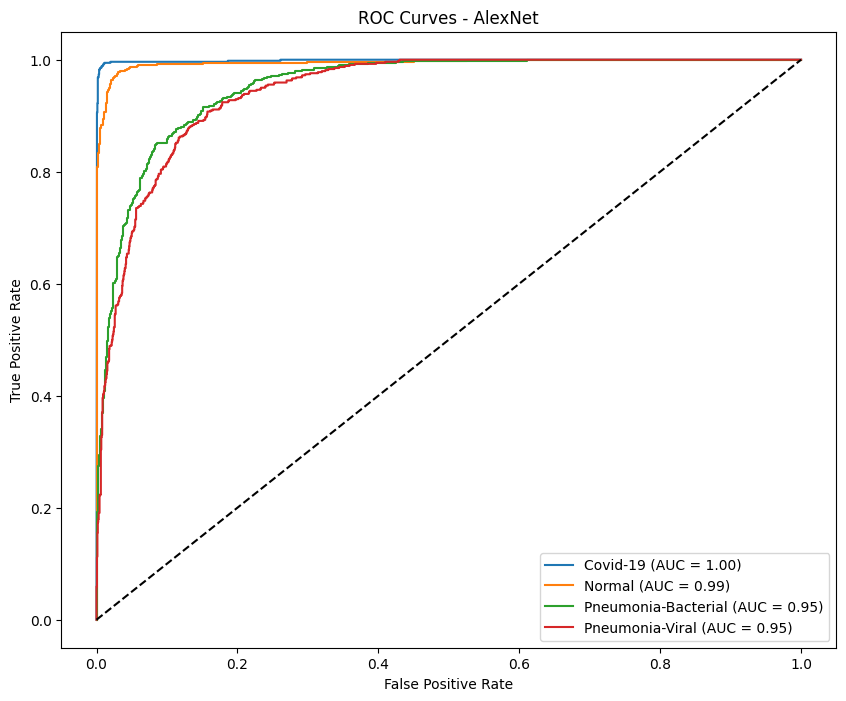

In [13]:
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    # Convert to binary for One-vs-Rest ROC
    y_true_bin = to_categorical(y_true, num_classes=4)[:, i]
    fpr, tpr, _ = roc_curve(y_true_bin, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - AlexNet')
plt.legend(loc='lower right')
plt.show()

In [1]:
import json

file = "alexNet_trained.ipynb"

with open(file, "r", encoding="utf-8") as f:
    nb = json.load(f)

# 🔥 Remove notebook-level widgets
nb.get("metadata", {}).pop("widgets", None)

# 🔥 Remove colab referenced widgets (just in case)
for cell in nb.get("cells", []):
    if "metadata" in cell and "colab" in cell["metadata"]:
        cell["metadata"]["colab"].pop("referenced_widgets", None)

with open(file, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("✅ Fully cleaned notebook (widgets removed)")

✅ Fully cleaned notebook (widgets removed)
